In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from lith_dictionary import lith_dict

In [2]:
catchment = pd.read_csv('Catchment_simple.csv', low_memory=False)
shapes = pd.read_csv('Catchments.csv', low_memory=False)
lith = pd.read_csv('Lithology_in_catchment.csv')
lith.replace({'lithology':lith_dict}, inplace = True)
assays = pd.read_csv('RTX_NURE_STREAM_FNL.csv')
assays.set_index('SAMPLEID', inplace = True)

lith_na_list = lith[lith.isnull()['lithology']]['objectid_1'].tolist()
clean_lith = lith[~lith.objectid_1.isin(lith_na_list)]
clean_lith_plot = pd.melt(clean_lith, id_vars = ['lithology'], value_vars = ['AREA'])

lith_area = pd.pivot_table(lith, index = 'objectid_1', values = 'AREA', columns = 'lithology').fillna(0)
lith_pct = pd.pivot_table(lith, index = 'objectid_1', values = 'PERCENTAGE', columns = 'lithology').fillna(0)
catchment.set_index('objectid', inplace = True)

lith = lith_pct.join(catchment)

In [3]:
rtx_sample_list = pd.read_pickle(r'rtx_sample_list.pkl')

In [4]:
lith['SAMPLEID'] = pd.to_numeric(lith['sampleid'],  errors='coerce')
lith.dropna(subset=['SAMPLEID'], inplace = True)
lith.set_index('SAMPLEID', inplace = True)

In [5]:
#Removed Au
simplified_geo = ['undifferentiated', 'granitic', 'intermediate', 'carbonate', 'sedimentary', 'shale',  'basaltic',  'sandstone',  'carbonates',  'ultramafic']
assay_cols = ['WGS84_WORLD_LL_Calc_X', 'WGS84_WORLD_LL_Calc_Y', 'Ag_ppm', 'Al_pct', 'As_ppm', 'Ba_ppm', 'Be_ppm', 'Bi_ppm', 'Ca_pct', 'Cd_ppm', 'Ce_ppm', 'Co_ppm', 'Cr_ppm',  'Cs_ppm', 'Cu_ppm', 'Fe_pct','Ga_ppm', 'Ge_ppm','Hf_ppm','In_ppm','K_pct','La_ppm','Li_ppm','Mg_pct', 'Mn_ppm', 'Mo_ppm', 'Na_pct', 'Nb_ppm', 'Ni_ppm','P_ppm', 'Pb_ppm', 'Rb_ppm', 'S_pct', 'Sb_ppm', 'Sc_ppm', 'Se_ppm','Sn_ppm', 'Sr_ppm', 'Ta_ppm', 'Te_ppm', 'Th_ppm', 'Ti_pct', 'Tl_ppm','U_ppm', 'V_ppm', 'W_ppm', 'Y_ppm', 'Zn_ppm', 'Zr_ppm']

In [6]:
lith_assay = lith[simplified_geo].join(assays[assay_cols])
lith_final_assay = lith_assay[lith_assay.index.isin(rtx_sample_list)]
#lith_assay = lith_assay.join(lith[['st_perimeter(shape)', 'st_area(shape)']])
#lith_assay.rename(columns={'st_perimeter(shape)': "Shape_Length", "st_area(shape)": "Shape_Area"}, inplace = True)

In [7]:
shapes_sort = shapes.sort_values('st_area(shape)', ascending=False).drop_duplicates('sampleid').sort_index()
shapes_sort['SAMPLEID'] = pd.to_numeric(shapes_sort['sampleid'],  errors='coerce')
shapes_no_dup = shapes_sort.set_index('SAMPLEID')
shapes_no_dup
lith_assay_shapes = lith_assay.join(shapes_no_dup[['st_area(shape)','st_perimeter(shape)']])
lith_assay_shapes.rename(columns={'st_perimeter(shape)': 'Shape_Length', 'st_area(shape)': 'Shape_Area'})
clean_lith_assay = lith_assay_shapes[lith_assay.index.isin(rtx_sample_list)]
clean_lith_assay

,undifferentiated,granitic,intermediate,carbonate,sedimentary,shale,basaltic,sandstone,carbonates,ultramafic,...,Ti_pct,Tl_ppm,U_ppm,V_ppm,W_ppm,Y_ppm,Zn_ppm,Zr_ppm,st_area(shape),st_perimeter(shape)
SAMPLEID,,,,,,,,,,,,,,,,,,,,,
40309500.0,11.480104,44.259948,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.322,0.553,1.99,71.5,1.015,19.75,99.2,81.0,3.583693e+05,5179.689995
40309951.0,40.074217,17.911863,0.0,0.0,0.0,0.0,1.939704,0.0,0.0,0.0,...,0.401,0.553,2.02,67.1,1.590,24.70,103.5,117.5,3.021326e+06,10291.751320
40309952.0,0.280067,0.000000,0.0,0.0,0.0,0.0,99.719933,0.0,0.0,0.0,...,0.451,0.426,1.63,81.0,1.235,18.70,97.5,111.5,1.519662e+03,161.427895
40309501.0,46.307993,45.510122,0.0,0.0,0.0,0.0,8.181884,0.0,0.0,0.0,...,0.278,0.823,4.00,49.2,1.450,31.40,60.5,116.0,1.087281e+07,24530.217250
40309953.0,22.957924,77.042076,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.393,3.260,3.34,81.1,12.350,30.60,146.0,109.0,3.194753e+05,4068.381234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40311859.0,43.228491,56.771510,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.246,0.212,1.71,103.5,7.820,13.20,91.1,13.9,NaN,NaN
40311860.0,100.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.299,0.220,2.01,195.5,1.310,24.30,222.0,18.8,1.485142e+04,687.050191
40311931.0,100.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.974,0.170,1.46,252.0,19.900,20.70,137.0,45.8,3.691792e+06,15068.356360


<Axes: xlabel='value', ylabel='lithology'>

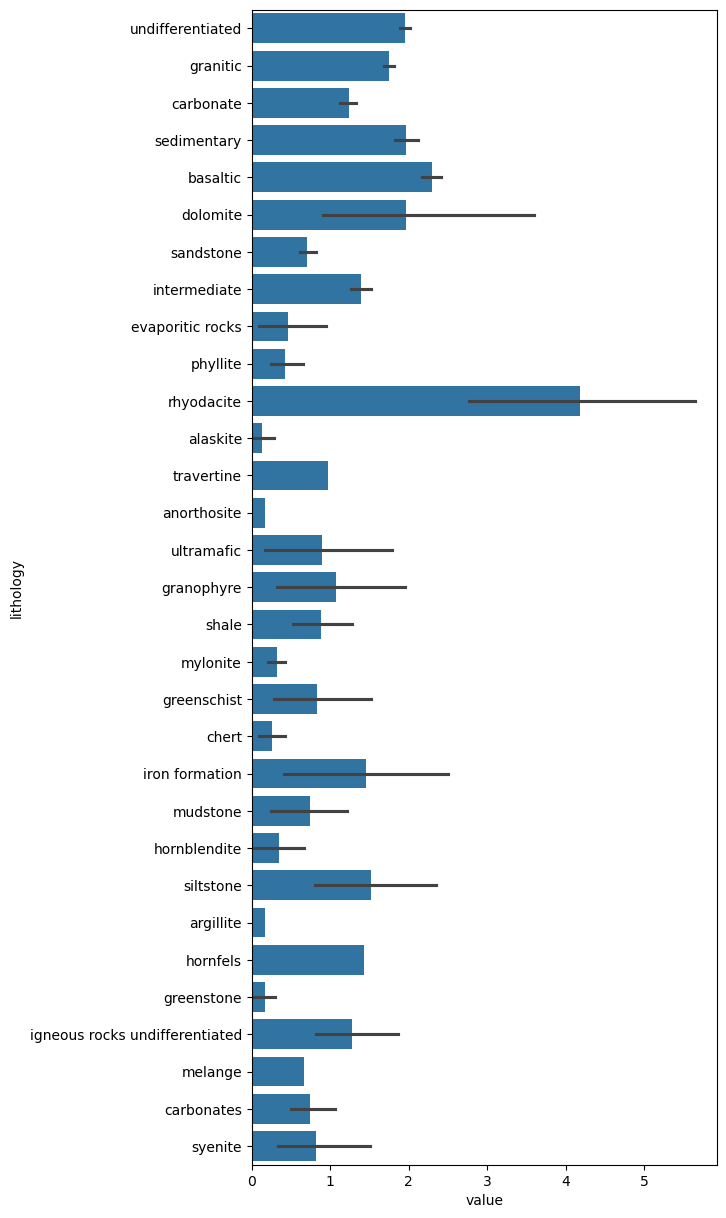

In [8]:
f, ax = plt.subplots(figsize=(6, 15))
sns.barplot(data = clean_lith_plot, y = 'lithology', x = 'value')

In [42]:
reduced_lith_assay_catch = clean_lith_assay

watershed_tab_lists = ["Phyllosilicates", "Gossan", "Mag", "Uranium"]
watershed_col_names = ['OBJECTID', 'SAMPLEID', 'COUNT', 'AREA', 'MIN', 'MAX', 'RANGE', 'MEAN', 'STD', 'SUM', 'VARIETY', 'MAJORITY',	'MAJORITY_COUNT', 'MAJORITY_PERCENT', 'MINORITY','MINORITY_COUNT', 'MINORITY_PERCENT', 'MEDIAN', 'PCT90']
table_name = 'TAB'

full_list = []
i = 0
for sheet in watershed_tab_lists:
    if i == 0:    
        table_col_names = [sheet+'_'+x for x in watershed_col_names]
        table_col_names[0] = 'SAMPLEID'
        table_col_names[2] = 'COUNT'
        new_table = pd.read_excel('Watershed_Sampling_SBCA.xlsx', sheet_name = sheet, names = table_col_names)
        new_table = new_table[~new_table.index.duplicated(keep='first')]
        new_table = new_table.set_index('SAMPLEID')
        table_col_names_subset = [table_col_names[1], table_col_names[2], table_col_names[7], table_col_names[8], table_col_names[11], table_col_names[13], table_col_names[14], table_col_names[16]]
        reduced_lith_assay_catch = reduced_lith_assay_catch.join(new_table[table_col_names_subset[1:]])
    else:
        table_col_names = [sheet+'_'+x for x in watershed_col_names]
        table_col_names[0] = 'SAMPLEID'
        new_table = pd.read_excel('Watershed_Sampling_SBCA.xlsx', sheet_name = sheet, names = table_col_names)
        new_table = new_table[~new_table.index.duplicated(keep='first')]
        new_table = new_table.set_index('SAMPLEID')
        table_col_names_subset = [table_col_names[7], table_col_names[8], table_col_names[11], table_col_names[13], table_col_names[14], table_col_names[16]]
        reduced_lith_assay_catch = reduced_lith_assay_catch.join(new_table[table_col_names_subset])
    full_list = full_list + table_col_names_subset
    i+=1

In [43]:
new_table

,Uranium_SAMPLEID,Uranium_COUNT,Uranium_AREA,Uranium_MIN,Uranium_MAX,Uranium_RANGE,Uranium_MEAN,Uranium_STD,Uranium_SUM,Uranium_VARIETY,Uranium_MAJORITY,Uranium_MAJORITY_COUNT,Uranium_MAJORITY_PERCENT,Uranium_MINORITY,Uranium_MINORITY_COUNT,Uranium_MINORITY_PERCENT,Uranium_MEDIAN,Uranium_PCT90
SAMPLEID,,,,,,,,,,,,,,,,,,
40311933,1,4033,0.000040,23,23,0,23.000000,0.000000,92759,1,23,4033,100.0000,23,4033,100.0000,23,23
40311937,2,12670,0.000126,16,23,7,17.651381,2.971970,223643,2,16,9681,76.4088,23,2989,23.5912,16,23
40311938,3,4093,0.000041,16,23,7,18.724408,3.412983,76639,2,16,2500,61.0799,23,1593,38.9201,16,23
40311936,4,9542,0.000095,16,23,7,16.018340,0.357832,152847,2,16,9517,99.7380,23,25,0.2620,16,16
40311934,5,12004,0.000119,16,16,0,16.000000,0.000000,192064,1,16,12004,100.0000,16,12004,100.0000,16,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40430497,1480,115526,0.001150,2,31,29,13.358603,6.045458,1543266,6,12,61311,53.0712,25,2385,2.0645,12,21
40428089,1481,12289,0.000122,2,2,0,2.000000,0.000000,24578,1,2,12289,100.0000,2,12289,100.0000,2,2
40304202,1482,4533,0.000045,23,23,0,23.000000,0.000000,104259,1,23,4533,100.0000,23,4533,100.0000,23,23


In [44]:
reduced_lith_assay_catch.to_csv('joined_data_RTX_streams_SBCA.csv', index=True)

In [48]:
lith_assay[lith_assay.index.isin(rtx_sample_list)].to_csv('joined_data_RTX_streams_SBCA.csv', index=False)